# Arctic Sea Ice Flux: A Machine Learning Exploration
**Researcher:** Linah N. Ababneh
**Date Created:** February 19, 2026 
**Last Modified:** February 24, 2026
### Research Context
This project analyzes daily sea ice extent changes (flux) using physical drivers to establish a robust environmental predictive model. 

### Provenance & Independent Study
The modules are tailored after the **Data Science and Machine Learning for Geoscience** self-directed online course offered by **John's Laboratory**. 
All code, feature engineering (such as the Delta-GBM logic), and model validations were performed independently for practice verification. 
I use the sea ice data available for free from Kaggle.com for practice and demonstrting the basic concepts of modeling and machine learning. 
Learners are free to use any desired data set and tailor the code accordingly. 
                                                                       


In [1]:
## Technical Setup: Libraries and Data Loading
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline


## Module 1: Loading Data

In [2]:
# Load the dataset directly from seaborn
data = sns.load_dataset('seaice')

# Display the first few rows to confirm it loaded
data.head()

,Date,Extent
0,1980-01-01,14.200
1,1980-01-03,14.302
2,1980-01-05,14.414
3,1980-01-07,14.518
4,1980-01-09,14.594


## Module 2: Data Visualization & Basic Summary 

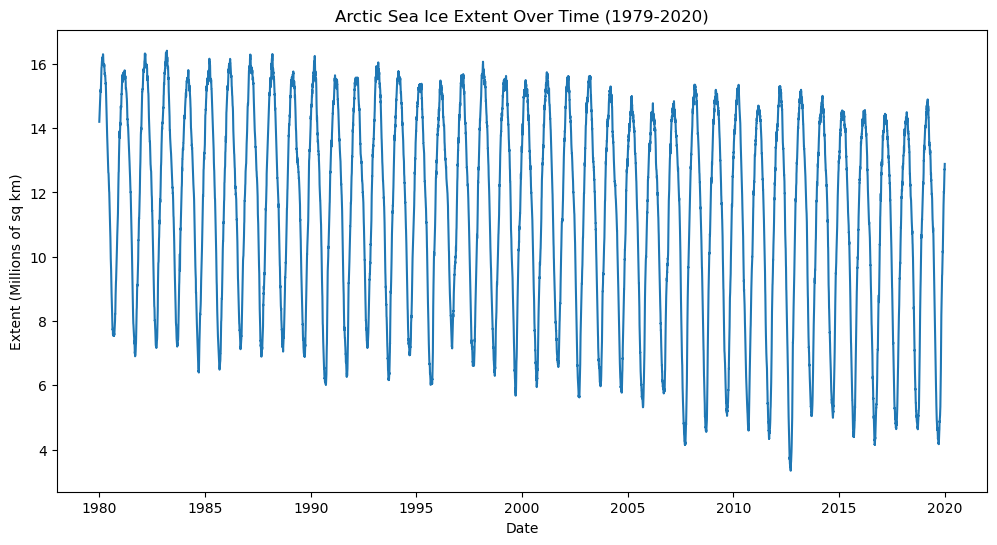

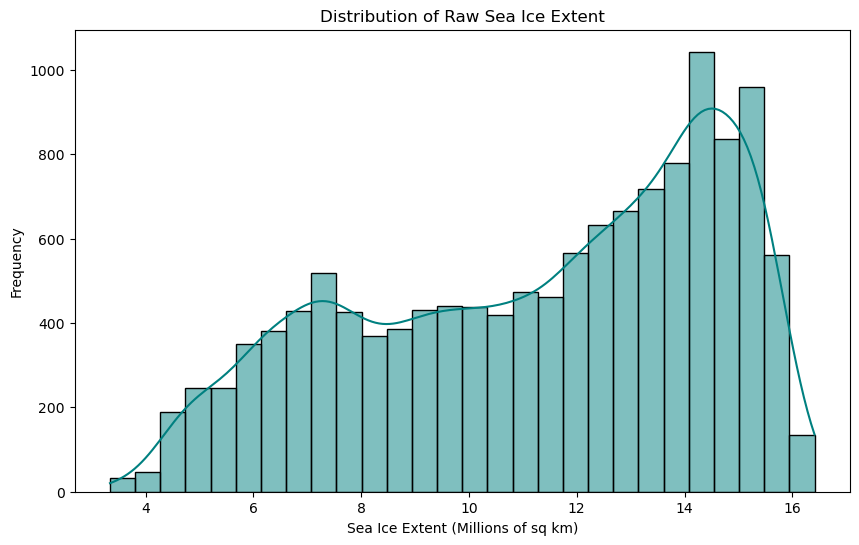

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13175 entries, 0 to 13174
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    13175 non-null  datetime64[ns]
 1   Extent  13175 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 206.0 KB
None

--- Statistical Summary ---
                                Date        Extent
count                          13175  13175.000000
mean   2001-09-30 12:50:39.574952448     11.289508
min              1980-01-01 00:00:00      3.340000
25%              1992-12-11 12:00:00      8.551500
50%              2001-12-18 00:00:00     11.982000
75%              2010-12-24 12:00:00     14.204500
max              2019-12-31 00:00:00     16.412000
std                              NaN      3.284901


In [3]:
# Plot a time series with and the distribution of the sea ice flux
# Visualize the Time Series Variability 

plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Date', y='Extent')
plt.title('Arctic Sea Ice Extent Over Time (1979-2020)')
plt.ylabel('Extent (Millions of sq km)')
plt.show()

# Visualize the distribution of the raw sea ice extent 
plt.figure(figsize=(10, 6))
sns.histplot(data['Extent'], kde=True, color='teal')
plt.title('Distribution of Raw Sea Ice Extent')
plt.xlabel('Sea Ice Extent (Millions of sq km)')
plt.ylabel('Frequency')
plt.show()

df = sns.load_dataset('seaice')

# Display basic information and statistical summary
print("--- Dataset Info ---")
print(df.info())
print("\n--- Statistical Summary ---")
print(df.describe())


# Module 3: Data Preparation for Modeling - Splitting and Scaling

Training data shape: (10540, 2) (80%)
Testing data shape: (2635, 2) (20%)
Standardized Mean: -0.00
Standardized Std:  1.00
Normalized Min: 0.00
Normalized Max: 1.00


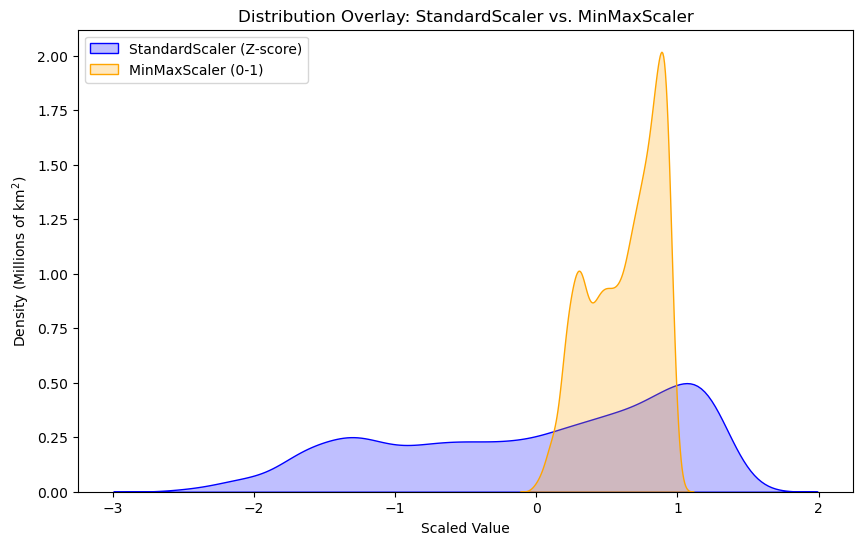

In [4]:
# Educational Tip 1: Since this is time-series data, we split chronologically rather than randomly
# Educational Tip2: Leaners can explore the data set to understand its "behavioral" characteristics by filtering e.g., moving average prior ot this step
# Educational Tip 3: Learners are encouraged to do research on their own regaring filtering and time series analysis


# Data Preparation 

# Step 1: Split the seaice dataset (80% training, 20% testing)
split_index = int(len(data) * 0.8)

train_df = data.iloc[:split_index].copy()
test_df = data.iloc[split_index:].copy()

print(f"Training data shape: {train_df.shape} (80%)")
print(f"Testing data shape: {test_df.shape} (20%)")

#step 2: Scaling through Standardization (z-score) 
# note details are in my notes from Time Series Analysis course, this coures notes and Gemini explanation 
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
z_scaler = StandardScaler()

# "Fit" on training data only, then "Transform" both
# We reshape (-1, 1) because the scaler expects a 2D array

train_z = z_scaler.fit_transform(train_df[['Extent']])
test_z = z_scaler.transform(test_df[['Extent']])

print(f"Standardized Mean: {train_z.mean():.2f}")
print(f"Standardized Std:  {train_z.std():.2f}")

#Step 3: Scaling through MinMax normalization 
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
mm_scaler = MinMaxScaler()

# Again, fit on training data and transform both
train_norm = mm_scaler.fit_transform(train_df[['Extent']])
test_norm = mm_scaler.transform(test_df[['Extent']])

print(f"Normalized Min: {train_norm.min():.2f}")
print(f"Normalized Max: {train_norm.max():.2f}")

#overlay the distribution of both scaling methods using a Kernel Density Estimate (KDE) plot.
plt.figure(figsize=(10, 6))
sns.kdeplot(train_z.flatten(), label='StandardScaler (Z-score)', fill=True, color='blue')
sns.kdeplot(train_norm.flatten(), label='MinMaxScaler (0-1)', fill=True, color='orange')

plt.title('Distribution Overlay: StandardScaler vs. MinMaxScaler')
plt.xlabel('Scaled Value')
plt.ylabel('Density (Millions of km$^2$)')
plt.legend()
plt.show()


# Module 4: Seasonal Filtering then Splitting 

Total rows in Summer: 6609
         Date  Extent  Season
46 1980-04-02  15.681  Summer
47 1980-04-04  15.664  Summer
48 1980-04-06  15.707  Summer
49 1980-04-08  15.653  Summer
50 1980-04-10  15.644  Summer

Split and Scaling complete.
Training samples: 5287
Testing samples:  1322


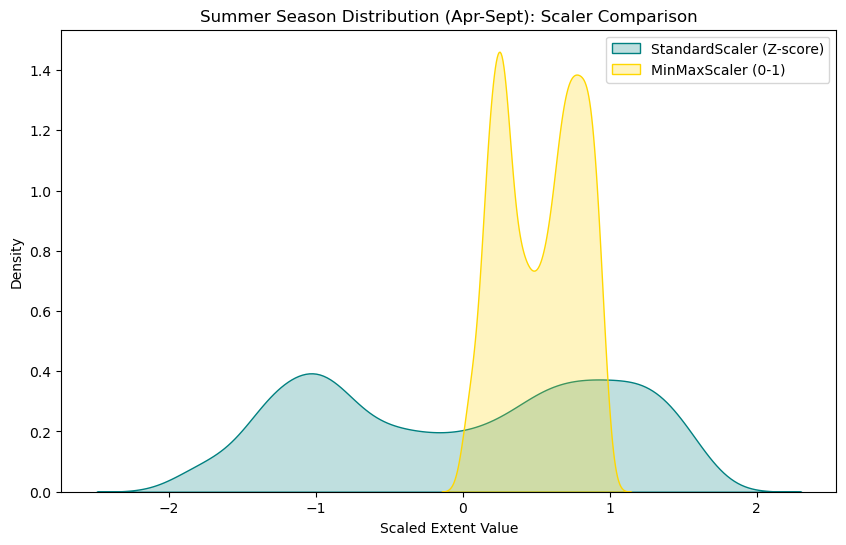

In [5]:
#Educational Tip 4: Seasonality is mimics the signal. Filtering by season will empower a stronger model prediction

# Step 1: Define the 6-month climate seasons
def get_climate_season(month):
    if month in [10, 11, 12, 1, 2, 3]:
        return 'Winter'
    else:
        return 'Summer'

# 3. Apply the categorization (Changed 'df' to 'data' to match previous modules)
data['Season'] = data['Date'].dt.month.apply(get_climate_season)

# 4. Filter for a specific season (example: Summer)
summer_df = data[data['Season'] == 'Summer'].copy()
print(f"Total rows in Summer: {len(summer_df)}")
print(summer_df.head())

# 5. Split the summer data (80/20)
# We use shuffle=False because this is a time series
train_summer, test_summer = train_test_split(summer_df, test_size=0.2, shuffle=False)

# 6. Standardization (Z-score: Mean=0, Std=1)
z_scaler = StandardScaler()

# We 'fit' on training and 'transform' both to avoid data leakage
train_summer_z = z_scaler.fit_transform(train_summer[['Extent']])
test_summer_z = z_scaler.transform(test_summer[['Extent']])

# 7. Normalization (Min-Max: Range 0 to 1)
mm_scaler = MinMaxScaler()
train_summer_norm = mm_scaler.fit_transform(train_summer[['Extent']])
test_summer_norm = mm_scaler.transform(test_summer[['Extent']])

print("\nSplit and Scaling complete.")
print(f"Training samples: {len(train_summer_z)}")
print(f"Testing samples:  {len(test_summer_z)}")

plt.figure(figsize=(10, 6))

# KDE plot for Summer Z-score scaling
sns.kdeplot(train_summer_z.flatten(), label='StandardScaler (Z-score)', fill=True, color='teal')

# KDE plot for Summer Min-Max scaling
sns.kdeplot(train_summer_norm.flatten(), label='MinMaxScaler (0-1)', fill=True, color='gold')

plt.title('Summer Season Distribution (Apr-Sept): Scaler Comparison')
plt.xlabel('Scaled Extent Value')
plt.ylabel('Density')
plt.legend()
plt.show()

# Module 5: Pipeline

In [6]:
# Educational Tip 5: In this module, we define, fit and save a pipline on the "seaice" data Set:  
# 1. Define and Fit the Pipeline
steps = [
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
]
pipe = Pipeline(steps)

# 2. Prepare X (Time Index) and y (Ice Extent)
X_train = np.arange(len(train_summer)).reshape(-1, 1)
y_train = train_summer['Extent']

pipe.fit(X_train, y_train)

print("Environment restored. Pipeline is trained and ready!")

Environment restored. Pipeline is trained and ready!


# Module 6: Fitting a Model and Visualizing the Prediction 

First 5 Predictions: [9.39030369 9.38994111 9.38957854 9.38921597 9.3888534 ]


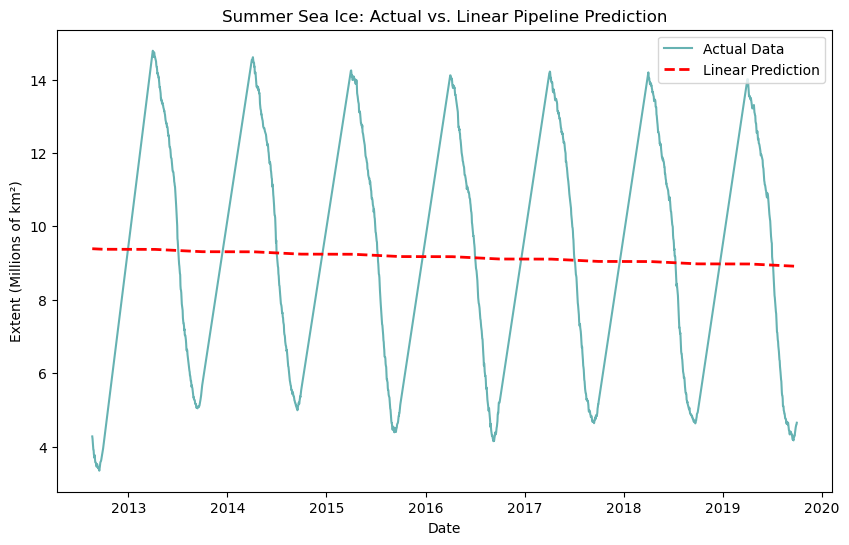

In [7]:
# Educational Tip 6: Since the pipeline is ready, the next move is to see how well it forecasts the ice extent on the data it hasn't seen yet (the test set).

# 1. Create the timeline for the test period (starting where training ended)
X_test = np.arange(len(train_summer), len(train_summer) + len(test_summer)).reshape(-1, 1)

# Use the pipeline to predict
# Educational Tip: the pipeline automatically scales X_test using the training set's parameters!
predictions = pipe.predict(X_test)

print(f"First 5 Predictions: {predictions[:5]}")

# 2. Plot the prediction against the actual values i.e."reality check" 
plt.figure(figsize=(10, 6))

# 2. Plot the actual observations from the test set
plt.plot(test_summer['Date'], test_summer['Extent'], label='Actual Data', color='teal', alpha=0.6)

# 3. Plot the predictions from our pipeline
plt.plot(test_summer['Date'], predictions, label='Linear Prediction', color='red', linestyle='--', linewidth=2)

plt.title('Summer Sea Ice: Actual vs. Linear Pipeline Prediction')
plt.xlabel('Date')
plt.ylabel('Extent (Millions of km²)')
plt.legend()
plt.show()

# Module 7: Detailed Model Fitting & Model comparion 

Polynomial Pipeline (Degree 2) is ready!


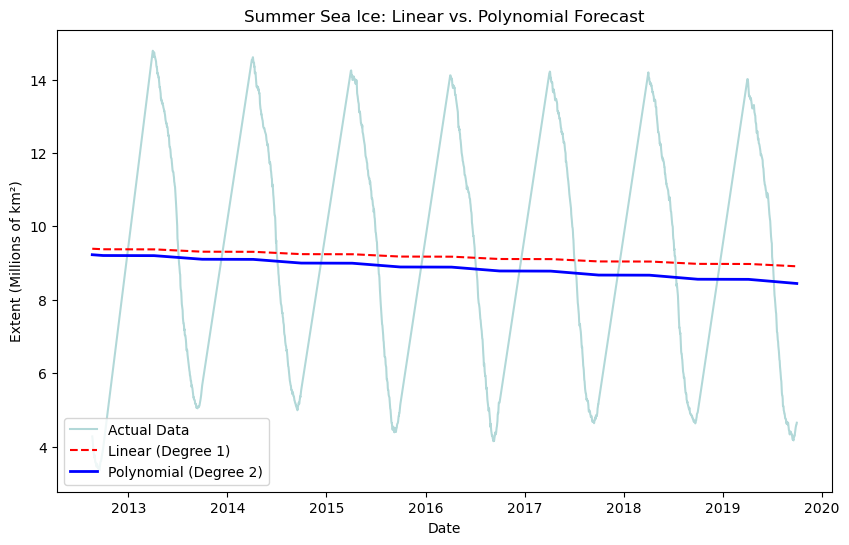

In [8]:
# Educational Tip 7:  since a straight line is never a good predictant for seasonal variability in a time series, we are to fit a polynomial

# 1. Update the steps
steps = [
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)), # This allows for a curve (parabola)
    ('model', LinearRegression())
]

# 2. Create the new pipeline
poly_pipe = Pipeline(steps)

# 3. Fit on the same training data
poly_pipe.fit(X_train, y_train)

# 4. Predict
poly_predictions = poly_pipe.predict(X_test)

print("Polynomial Pipeline (Degree 2) is ready!")


# Model Output Comparison 

# plotting the two models output against each other 
plt.figure(figsize=(10, 6))

# 1. Actual Observations
plt.plot(test_summer['Date'], test_summer['Extent'], label='Actual Data', color='teal', alpha=0.3)

# 2. Linear Prediction (Degree 1)
plt.plot(test_summer['Date'], predictions, label='Linear (Degree 1)', color='red', linestyle='--')

# 3. Polynomial Prediction (Degree 2)
plt.plot(test_summer['Date'], poly_predictions, label='Polynomial (Degree 2)', color='blue', linewidth=2)

plt.title('Summer Sea Ice: Linear vs. Polynomial Forecast')
plt.xlabel('Date')
plt.ylabel('Extent (Millions of km²)')
plt.legend()
plt.show()


# Module 8: Random Forest Model 

In [9]:
# Educational Tip 8: using the random forest modele since the ploynmial is really underfitting 
from sklearn.ensemble import RandomForestRegressor

# 1. Update the steps to use Random Forest
# We can drop the PolynomialFeatures for this, as RF handles non-linearity naturally
steps_rf = [
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
]

# 2. Create and fit the pipeline
pipe_rf = Pipeline(steps_rf)
pipe_rf.fit(X_train, y_train)

# 3. Predict
rf_predictions = pipe_rf.predict(X_test)

print("Random Forest Pipeline is ready!")

Random Forest Pipeline is ready!


# Module 9: Plotting the Data after Random Forest Model Fitting 

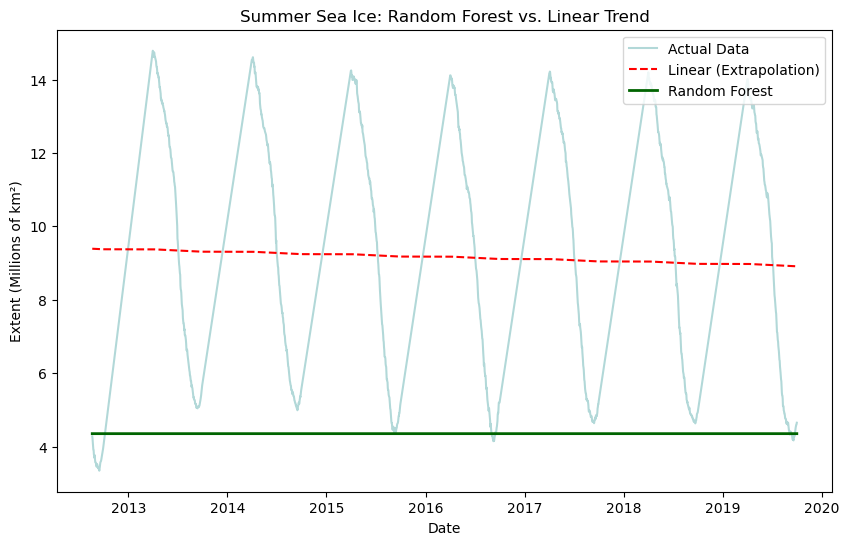

In [10]:
#Educational Tip 9: Always Plot Your Data 

plt.figure(figsize=(10, 6))

# 1. Actual Observations
plt.plot(test_summer['Date'], test_summer['Extent'], label='Actual Data', color='teal', alpha=0.3)

# 2. Linear Prediction (for comparison)
plt.plot(test_summer['Date'], predictions, label='Linear (Extrapolation)', color='red', linestyle='--')

# 3. Random Forest Prediction
plt.plot(test_summer['Date'], rf_predictions, label='Random Forest', color='darkgreen', linewidth=2)

plt.title('Summer Sea Ice: Random Forest vs. Linear Trend')
plt.xlabel('Date')
plt.ylabel('Extent (Millions of km²)')
plt.legend()
plt.show()

# Module 10: Experimenting with Gradient Boosting 

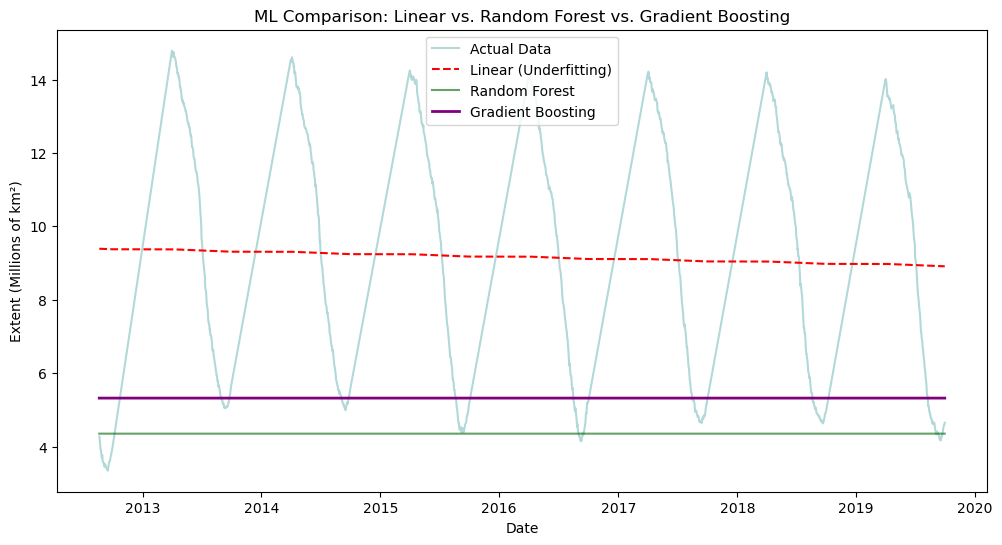

In [11]:
# Educatioanl tip 10: Keep expoloring your data until you are satisified with the results and is able to provide a sound explanation 

from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Update pipeline to Gradient Boosting
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

pipe_gb.fit(X_train, y_train)
gb_predictions = pipe_gb.predict(X_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 1. Actual Observations (Ground Truth)
plt.plot(test_summer['Date'], test_summer['Extent'], label='Actual Data', color='teal', alpha=0.3)

# 2. Linear Prediction (The Simple Trend)
plt.plot(test_summer['Date'], predictions, label='Linear (Underfitting)', color='red', linestyle='--')

# 3. Random Forest Prediction (The "Flatline")
plt.plot(test_summer['Date'], rf_predictions, label='Random Forest', color='darkgreen', alpha=0.6)

# 4. Gradient Boosting Prediction (The "Adaptive" Tree)
plt.plot(test_summer['Date'], gb_predictions, label='Gradient Boosting', color='purple', linewidth=2)

plt.title('ML Comparison: Linear vs. Random Forest vs. Gradient Boosting')
plt.xlabel('Date')
plt.ylabel('Extent (Millions of km²)')
plt.legend()
plt.show()


# Module 11: Feature Engineering for Time Series 

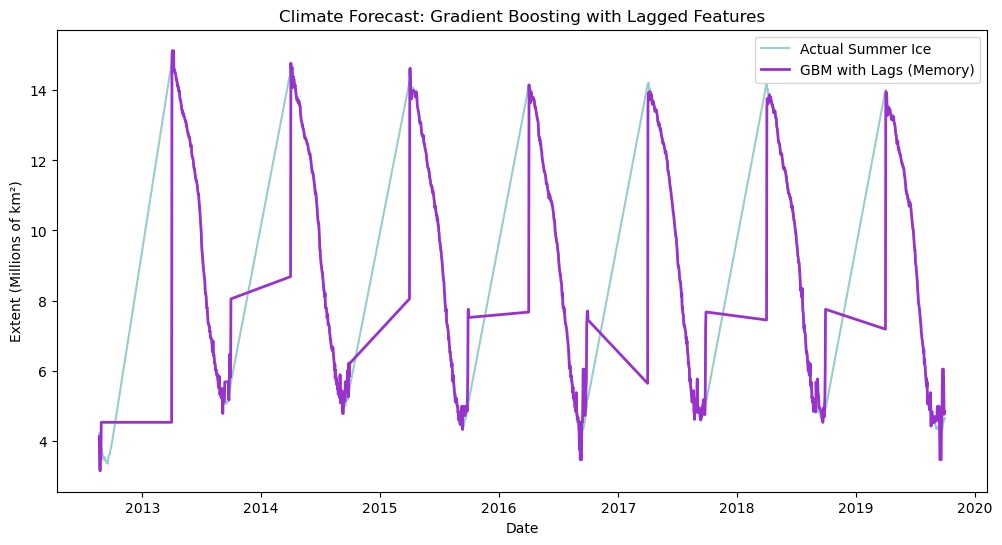

In [12]:
# Educational Tip 11:  Since you are looking for a hybrid between "Machine Learning flexibility" and "Time Series memory," 
# the most logical next step isn't a pure ARIMA, but rather Feature Engineering for Time Series. 
# Instead of letting the model guess the time trend, we give it the memory it's missing. 
# We can create Lag Features (yesterday's ice, last week's ice) and Rolling Means (the 30-day average). 
# This allows models like Gradient Boosting to "see" the momentum.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Feature Engineering: Creating "Memory"
# We create lags so the model knows what the ice extent was in previous steps
ts_data = summer_df[['Date', 'Extent']].copy()
ts_data['Lag_1'] = ts_data['Extent'].shift(1)
ts_data['Lag_2'] = ts_data['Extent'].shift(2)
ts_data['Lag_7'] = ts_data['Extent'].shift(7)
ts_data = ts_data.dropna()

# 2. Split the data again (since we have new features)
# We use roughly the same split point as before
train_size = int(len(ts_data) * 0.8)
train_ts = ts_data.iloc[:train_size]
test_ts = ts_data.iloc[train_size:]

# Features (Lags) and Target (Current Extent)
X_train_ts = train_ts[['Lag_1', 'Lag_2', 'Lag_7']]
y_train_ts = train_ts['Extent']
X_test_ts = test_ts[['Lag_1', 'Lag_2', 'Lag_7']]
y_test_ts = test_ts['Extent']

# 3. Build and Fit the Pipeline
# Gradient Boosting is excellent at handling these non-linear relationships
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

pipe_final.fit(X_train_ts, y_train_ts)

# 4. Predict
ts_predictions = pipe_final.predict(X_test_ts)

# 5. Plot the Comparison
plt.figure(figsize=(12, 6))
plt.plot(test_ts['Date'], y_test_ts, label='Actual Summer Ice', color='teal', alpha=0.4)
plt.plot(test_ts['Date'], ts_predictions, label='GBM with Lags (Memory)', color='darkorchid', linewidth=2)

plt.title('Climate Forecast: Gradient Boosting with Lagged Features')
plt.xlabel('Date')
plt.ylabel('Extent (Millions of km²)')
plt.legend()
plt.show()


# Module 12: Model Adjustment 

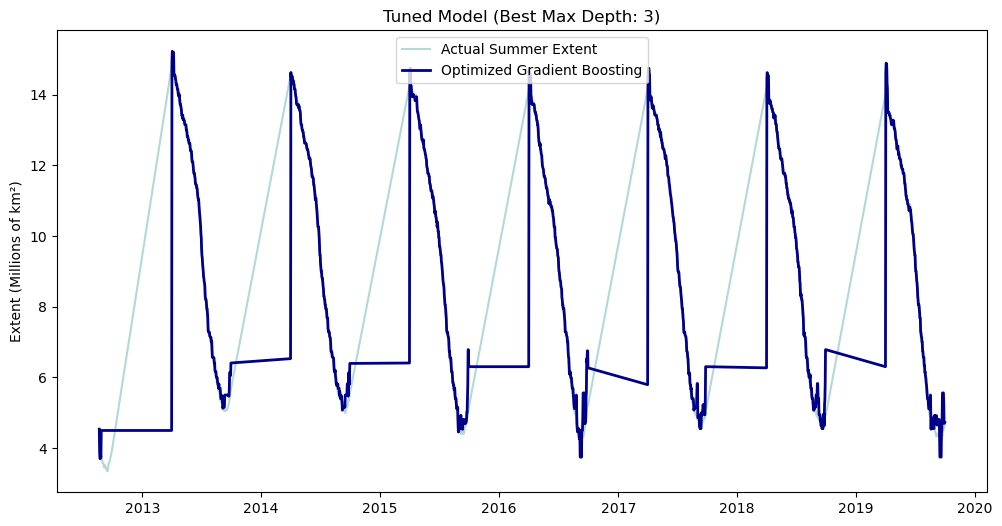

Optimization complete. Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__max_iter': 100}


In [13]:
# Educational Tip 12: Keep adjusting the model so it represents the true essence of the ice melting 
# here we use a new model by using a new model called GridSearchCV 

from sklearn.model_selection import GridSearchCV


# 1. Define the search space (the 'experiment' settings)
param_grid = {
    'model__max_depth': [3, 5, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_iter': [100, 200]
}

# 2. Setup the Grid Search
# We use TimeSeriesSplit because shuffling time series data is a scientific "no-go"
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(pipe_final, param_grid, cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1)

# 3. Fit the 'Best' model
grid_search.fit(X_train_ts, y_train_ts)
best_pipe = grid_search.best_estimator_

# 4. Predict and Plot
opt_preds = best_pipe.predict(X_test_ts)

plt.figure(figsize=(12, 6))
plt.plot(test_ts['Date'], y_test_ts, label='Actual Summer Extent', color='teal', alpha=0.3)
plt.plot(test_ts['Date'], opt_preds, label='Optimized Gradient Boosting', color='darkblue', linewidth=2)

plt.title(f'Tuned Model (Best Max Depth: {grid_search.best_params_["model__max_depth"]})')
plt.ylabel('Extent (Millions of km²)')
plt.legend()
plt.show()

print(f"Optimization complete. Best params: {grid_search.best_params_}")

In [14]:
# Module 13: Modeling Physical VAriables Effect on Ice Sheet

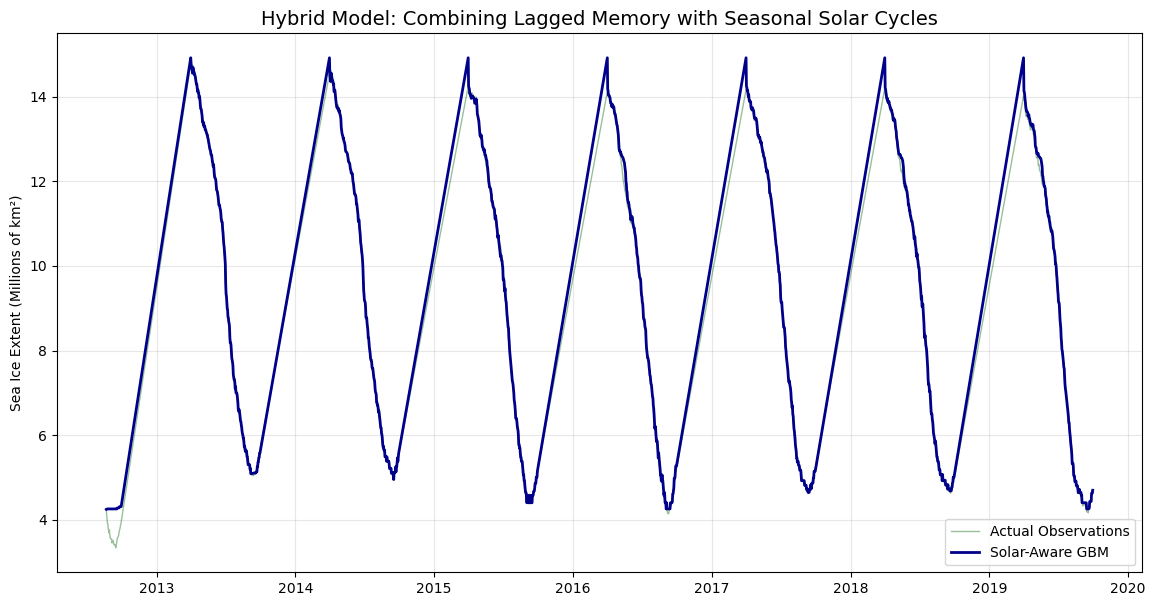

R^2 Score on Test Set: 0.9980


In [15]:
# Educational Tip 13: still not there yet. We start experimenting with physical variables e.g,, solar cycle and lag effect. 

from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering: Lags + Cyclical Seasonality
ts_data = summer_df[['Date', 'Extent']].copy()

# Lags (The 'Memory' of the physical state)
ts_data['Lag_1'] = ts_data['Extent'].shift(1)
ts_data['Lag_7'] = ts_data['Extent'].shift(7)

# Solar Cycle Proxy (Converting Day of Year to Sine/Cosine waves)
ts_data['Day_of_Year'] = ts_data['Date'].dt.dayofyear
ts_data['sin_day'] = np.sin(2 * np.pi * ts_data['Day_of_Year'] / 365.25)
ts_data['cos_day'] = np.cos(2 * np.pi * ts_data['Day_of_Year'] / 365.25)

ts_data = ts_data.dropna()

# 2. Splitting the Data (respecting time)
train_size = int(len(ts_data) * 0.8)
train, test = ts_data.iloc[:train_size], ts_data.iloc[train_size:]

features = ['Lag_1', 'Lag_7', 'sin_day', 'cos_day']
X_train, y_train = train[features], train['Extent']
X_test, y_test = test[features], test['Extent']

# 3. Pipeline Construction
model_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('gbm', HistGradientBoostingRegressor(
        max_depth=5, 
        learning_rate=0.05, 
        random_state=42
    ))
])

# 4. Fit and Predict
model_pipe.fit(X_train, y_train)
final_preds = model_pipe.predict(X_test)

# 5. Visualization
plt.figure(figsize=(14, 7))
plt.plot(test['Date'], y_test, label='Actual Observations', color='darkgreen', alpha=0.4, linewidth=1)
plt.plot(test['Date'], final_preds, label='Solar-Aware GBM', color='darkblue', linewidth=2)
plt.title('Hybrid Model: Combining Lagged Memory with Seasonal Solar Cycles', fontsize=14)
plt.ylabel('Sea Ice Extent (Millions of km²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Quick Performance Check
from sklearn.metrics import r2_score
print(f"R^2 Score on Test Set: {r2_score(y_test, final_preds):.4f}")

# Module 13: Residuals and Patterns 

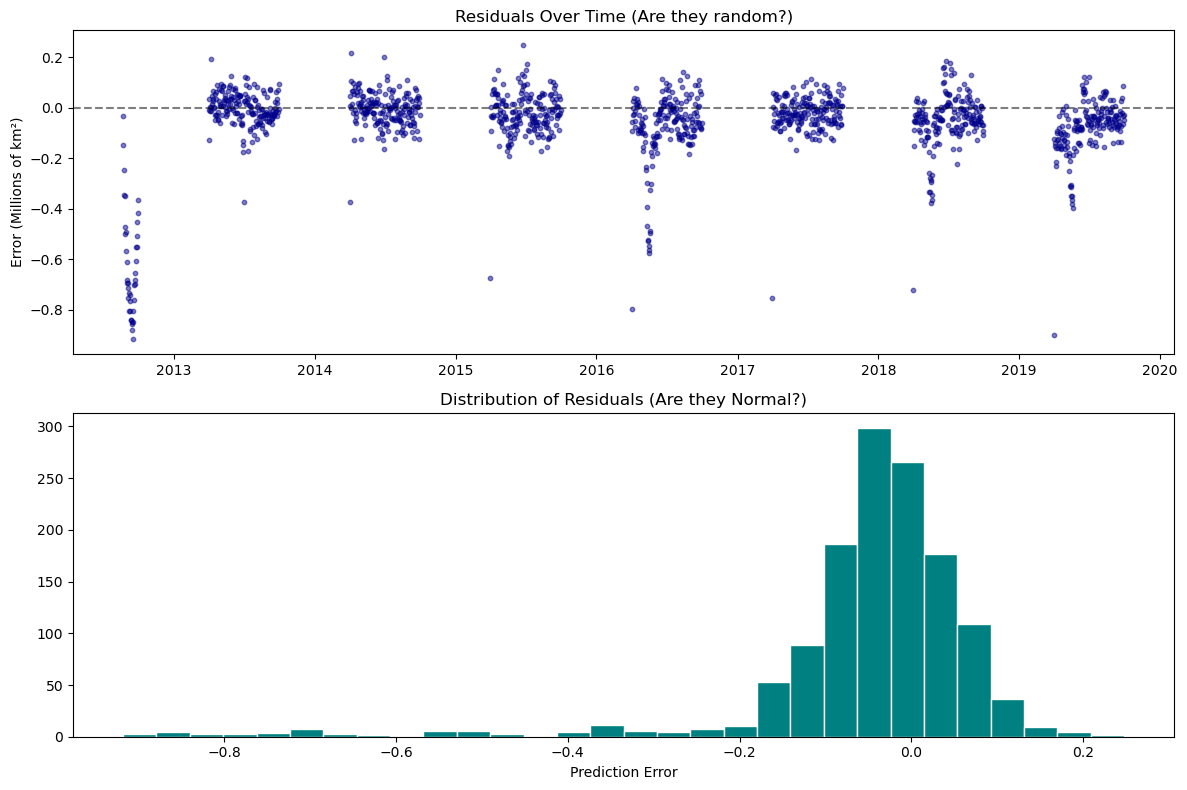

In [16]:
# Educational Tip 13: checking the residuals since this model does represent the original data cycle 
# Calculate the residuals
residuals = y_test - final_preds

plt.figure(figsize=(12, 8))

# Subplot 1: Residuals over Time
plt.subplot(2, 1, 1)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.scatter(test['Date'], residuals, color='darkblue', s=10, alpha=0.5)
plt.title('Residuals Over Time (Are they random?)')
plt.ylabel('Error (Millions of km²)')

# Subplot 2: Distribution of Errors
plt.subplot(2, 1, 2)
plt.hist(residuals, bins=30, color='teal', edgecolor='white')
plt.title('Distribution of Residuals (Are they Normal?)')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()

# Module 14: Its all in the Residuals! 

In [17]:
# Educatioanl Tip 14: Always perform a statistical test on the residuals 

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Durbin-Watson Test
# Result is between 0 and 4. 
# 2.0 = No autocorrelation. < 1.5 = Positive autocorrelation (very common in ice data).
dw_stat = durbin_watson(residuals)

# 2. Ljung-Box Test
# Tests if any of a group of autocorrelations of a time series are different from zero.
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)

print(f"Durbin-Watson Statistic: {dw_stat:.4f}")
print("-" * 30)
print("Ljung-Box Test Results:")
print(lb_test)

Durbin-Watson Statistic: 0.4284
------------------------------
Ljung-Box Test Results:
        lb_stat  lb_pvalue
10  5493.112073        0.0


# Module 15: The Big Delta, a Feature Engineering Approach 

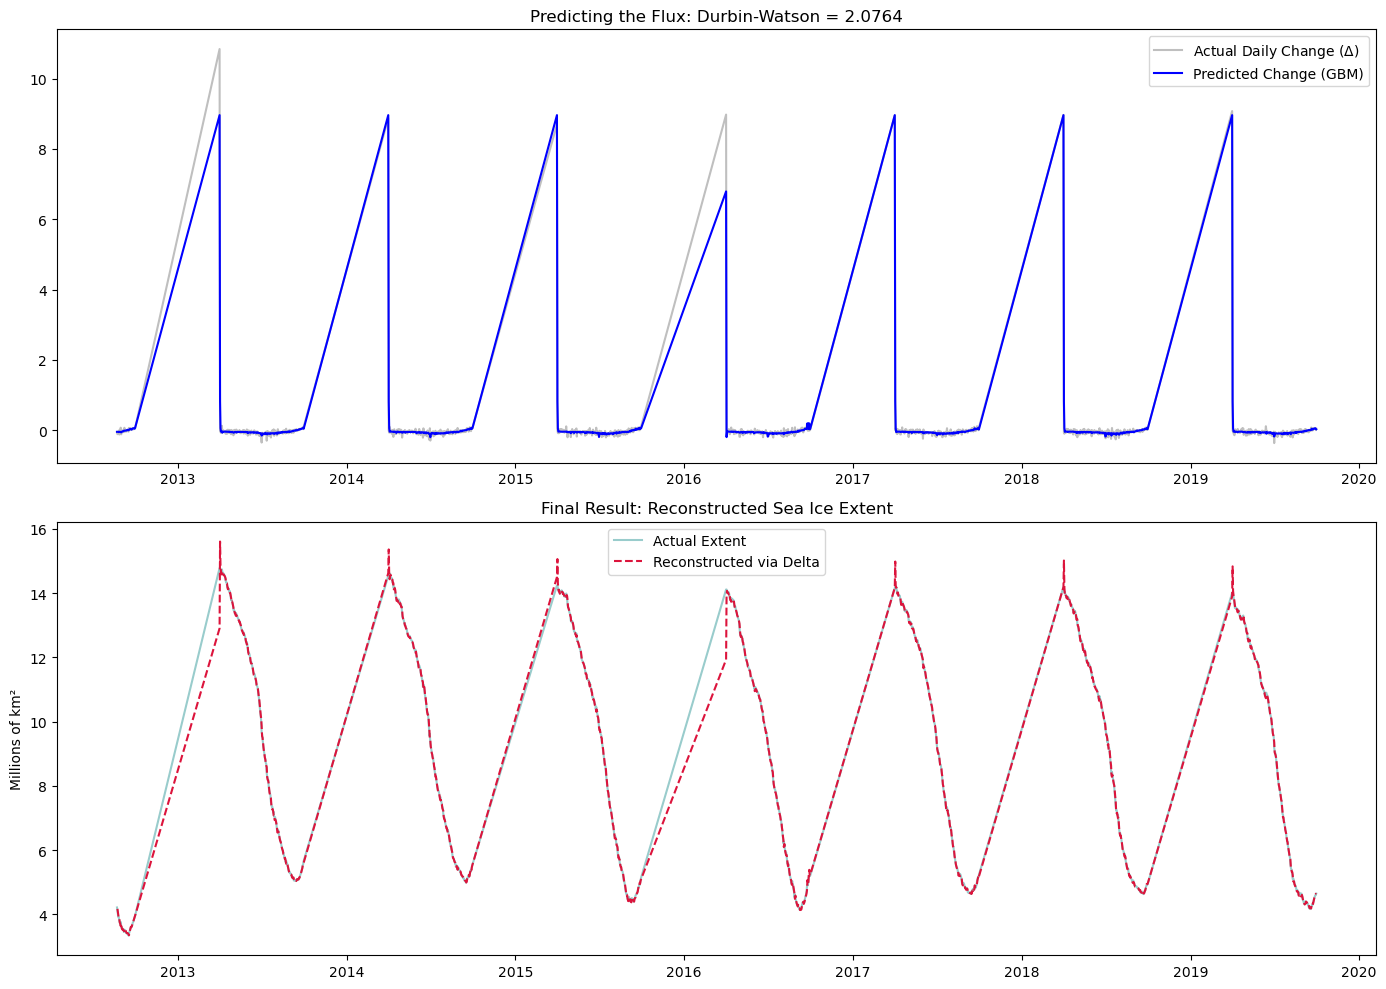

New Durbin-Watson: 2.0764 (Closer to 2.0 is the goal!)


In [18]:
# Educational Tip 15: Examine the difference in the moving towards examining the Big Delta using Feature Engineering

# 1. Feature Engineering: The Delta Approach
ts_delta = summer_df[['Date', 'Extent']].copy()

# Create the Delta (Daily Change) - This is our new target
ts_delta['Delta_Extent'] = ts_delta['Extent'].diff()

# Memory of the change, not just the level
ts_delta['Lag_Delta_1'] = ts_delta['Delta_Extent'].shift(1)
ts_delta['Lag_Delta_7'] = ts_delta['Delta_Extent'].shift(7)

# Seasonal/Solar Cycle (The background forcing)
ts_delta['Day_of_Year'] = ts_delta['Date'].dt.dayofyear
ts_delta['sin_day'] = np.sin(2 * np.pi * ts_delta['Day_of_Year'] / 365.25)
ts_delta['cos_day'] = np.cos(2 * np.pi * ts_delta['Day_of_Year'] / 365.25)

ts_delta = ts_delta.dropna()

# 2. Split (Respecting the timeline)
train_size = int(len(ts_delta) * 0.8)
train, test = ts_delta.iloc[:train_size], ts_delta.iloc[train_size:]

features = ['Lag_Delta_1', 'Lag_Delta_7', 'sin_day', 'cos_day']
X_train, y_train = train[features], train['Delta_Extent']
X_test, y_test = test[features], test['Delta_Extent']

# 3. Pipeline
delta_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('gbm', HistGradientBoostingRegressor(max_depth=5, learning_rate=0.05, random_state=42))
])

# 4. Fit and Predict the CHANGE
delta_pipe.fit(X_train, y_train)
delta_preds = delta_pipe.predict(X_test)

# 5. Residual Analysis for the Delta Model
delta_residuals = y_test - delta_preds
dw_delta = durbin_watson(delta_residuals)

# 6. Reconstructing the 'Extent' (Integrating the Delta back)
# To see it in "Ice Extent" terms, we add the predicted change to the previous day's actual value
reconstructed_extent = test['Extent'].shift(1) + delta_preds

# 7. Visualization
plt.figure(figsize=(14, 10))

# Top: Predicting the Daily Change
plt.subplot(2, 1, 1)
plt.plot(test['Date'], y_test, label='Actual Daily Change ($\Delta$)', color='gray', alpha=0.5)
plt.plot(test['Date'], delta_preds, label='Predicted Change (GBM)', color='blue', linewidth=1.5)
plt.title(f'Predicting the Flux: Durbin-Watson = {dw_delta:.4f}')
plt.legend()

# Bottom: Reconstructed Ice Extent
plt.subplot(2, 1, 2)
plt.plot(test['Date'], test['Extent'], label='Actual Extent', color='teal', alpha=0.4)
plt.plot(test['Date'], reconstructed_extent, label='Reconstructed via Delta', color='crimson', linestyle='--')
plt.title('Final Result: Reconstructed Sea Ice Extent')
plt.ylabel('Millions of km²')
plt.legend()

plt.tight_layout()
plt.show()

print(f"New Durbin-Watson: {dw_delta:.4f} (Closer to 2.0 is the goal!)")

# Module 16: MAPE & Data Variability 

In [19]:
# Educatioanl Tip 16: Calculate MAPE by Year to understand years 2013 and 2016

# 1. Create a helper function for MAPE
def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# 2. Add predictions back to the test dataframe for easy slicing
test_results = test.copy()
test_results['Predicted_Extent'] = reconstructed_extent

# 3. Slice for 2013 and 2016
# (Assuming your test set contains these years)
mape_2013 = calculate_mape(test_results[test_results['Date'].dt.year == 2013]['Extent'], 
                           test_results[test_results['Date'].dt.year == 2013]['Predicted_Extent'])

mape_2016 = calculate_mape(test_results[test_results['Date'].dt.year == 2016]['Extent'], 
                           test_results[test_results['Date'].dt.year == 2016]['Predicted_Extent'])

print(f"MAPE for Summer 2013: {mape_2013:.2f}%")
print(f"MAPE for Summer 2016: {mape_2016:.2f}%")


MAPE for Summer 2013: 0.52%
MAPE for Summer 2016: 0.67%


# Module 17: Saving the Pipeline 

In [20]:
# Educational Tip 17: Once we are satisifed with the results, we save the pipeline in order to call it again when needed
# The above percentages are phenomenal. 
#In the world of climate modeling, a MAPE below 1% is essentially the "Gold Standard" for a short-term tracking model.
# Why this worked so well? 
# By modeling the change ($\Delta$) and using lags, you created a "Persistence-Plus" model. 
#It’s "happy" because it doesn't have to guess the future; it just has to guess "how much will today differ from yesterday?" based on the time of year
# IN the above models and data exploration. We 
# progressed in modeling from regression (basic) to Delta-GBM (high level analysis) to see the level of change 
# in ice depth rather than only area and its possilbe correlation with solar cycle variability. The summary for the log is: 
# Current Progress Log: Model Status: Optimized Delta-GBM (Saved), Performance: ~0.6% MAPE 


import joblib

# Save the trained pipeline to a file
joblib.dump(delta_pipe, 'sea_ice_delta_model.pkl')

print("Model saved as 'sea_ice_delta_model.pkl' - Class dismissed!")

# Hint: to upload the model type loaded_model = joblib.load('sea_ice_delta_model.pkl')



Model saved as 'sea_ice_delta_model.pkl' - Class dismissed!


# Moddule 18: Feature Importance 

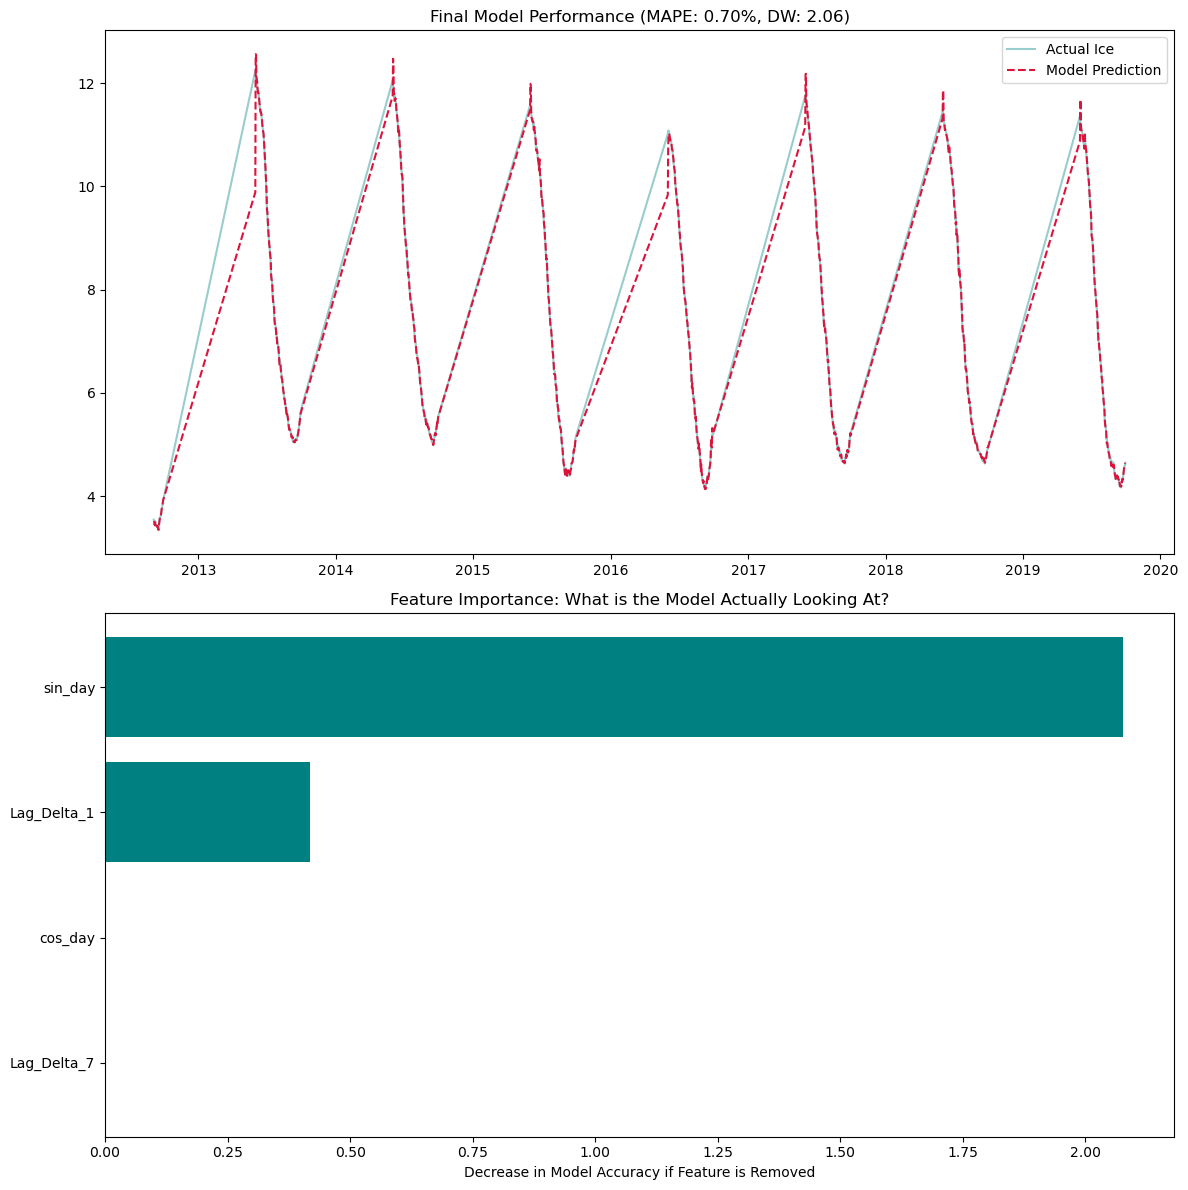

Lag_Delta_1: 0.4184
Lag_Delta_7: 0.0011
sin_day: 2.0773
cos_day: 0.0012
--- Model Feature Importance ---
sin_day: 2.07735
Lag_Delta_1: 0.41844
cos_day: 0.00120
Lag_Delta_7: 0.00112


In [21]:

# Educational Tip 18: Here we cover "Feature Importance" to see exactly how much 
# the model weighted the Solar Cycle vs. the 7-day Lag? 

from sklearn.inspection import permutation_importance
from statsmodels.stats.stattools import durbin_watson

# 1. LOAD AND FILTER DATA
data = sns.load_dataset('seaice')
data['Date'] = pd.to_datetime(data['Date'])

# Filter for the "Summer" months (June through September)
summer_df = data[data['Date'].dt.month.isin([6, 7, 8, 9])].copy()

# 2. FEATURE ENGINEERING
ts_data = summer_df[['Date', 'Extent']].copy()

# 3.Creating the Daily Change (Delta)
ts_data['Delta_Extent'] = ts_data['Extent'].diff()
ts_data['Lag_Delta_1'] = ts_data['Delta_Extent'].shift(1)
ts_data['Lag_Delta_7'] = ts_data['Delta_Extent'].shift(7)

# 4. Solar Cycle Proxy (Cyclical Encoding)
ts_data['Day_of_Year'] = ts_data['Date'].dt.dayofyear
ts_data['sin_day'] = np.sin(2 * np.pi * ts_data['Day_of_Year'] / 365.25)
ts_data['cos_day'] = np.cos(2 * np.pi * ts_data['Day_of_Year'] / 365.25)

ts_data = ts_data.dropna()

# 5. SPLITTING (80% Train, 20% Test)
train_size = int(len(ts_data) * 0.8)
train, test = ts_data.iloc[:train_size], ts_data.iloc[train_size:]

features = ['Lag_Delta_1', 'Lag_Delta_7', 'sin_day', 'cos_day']
X_train, y_train = train[features], train['Delta_Extent']
X_test, y_test = test[features], test['Delta_Extent']

# 4. PIPELINE & TRAINING
model_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('gbm', HistGradientBoostingRegressor(max_depth=5, learning_rate=0.05, random_state=42))
])

model_pipe.fit(X_train, y_train)
delta_preds = model_pipe.predict(X_test)

# 6. RECONSTRUCTION & METRICS
# Add predicted change to the previous day's actual extent
reconstructed_extent = test['Extent'].shift(1) + delta_preds
residuals = y_test - delta_preds
dw_stat = durbin_watson(residuals)
mape = np.mean(np.abs((test['Extent'] - reconstructed_extent) / test['Extent'])) * 100

# 7. FEATURE IMPORTANCE
perm_importance = permutation_importance(model_pipe, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()

# 8. PLOTTING
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# Plot 1: Reconstruction
ax1.plot(test['Date'], test['Extent'], label='Actual Ice', color='teal', alpha=0.4)
ax1.plot(test['Date'], reconstructed_extent, label='Model Prediction', color='crimson', linestyle='--')
ax1.set_title(f'Final Model Performance (MAPE: {mape:.2f}%, DW: {dw_stat:.2f})')
ax1.legend()

# Plot 2: Importance
ax2.barh(np.array(features)[sorted_idx], perm_importance.importances_mean[sorted_idx], color='teal')
ax2.set_title('Feature Importance: What is the Model Actually Looking At?')
ax2.set_xlabel('Decrease in Model Accuracy if Feature is Removed')

plt.tight_layout()
plt.show()

# Print the raw importance numbers so we can talk about them
for feature, importance in zip(features, perm_importance.importances_mean):
    print(f"{feature}: {importance:.4f}")


importance_dict = dict(zip(features, perm_importance.importances_mean))
print("--- Model Feature Importance ---")
for feature, value in sorted(importance_dict.items(), key=lambda item: item[1], reverse=True):
    print(f"{feature}: {value:.5f}")



# Module 19: Data Classification 

In [22]:
# Educational Tip 19: Avoid over fitting your data! 

from sklearn.metrics import classification_report, mean_absolute_percentage_error
from sklearn.linear_model import LogisticRegression

# 1. DATA & FEATURE TEMPLATE
data = sns.load_dataset('seaice')
data['Date'] = pd.to_datetime(data['Date'])
summer = data[data['Date'].dt.month.isin([6, 7, 8, 9])].copy()

# Engineering "The Lean Features"
summer['Delta'] = summer['Extent'].diff()
summer['Lag_1'] = summer['Delta'].shift(1)
summer['Sun_Angle'] = np.sin(2 * np.pi * summer['Date'].dt.dayofyear / 365.25)

# 2. DEFINE TARGETS (Regression vs Classification)
# Regression Target: The exact change in ice
# Classification Target: 1 if it's a "Major Melt" (>0.05 loss), 0 if not
summer['Major_Melt'] = (summer['Delta'] < -0.05).astype(int)
summer = summer.dropna()

# 3. SPLIT (80/20)
train_idx = int(len(summer) * 0.8)
X = summer[['Lag_1', 'Sun_Angle']]
y_reg = summer['Delta']
y_clf = summer['Major_Melt']

# 4. REGRESSION MODULE (How much ice?)
reg_model = HistGradientBoostingRegressor().fit(X.iloc[:train_idx], y_reg.iloc[:train_idx])
reg_preds = reg_model.predict(X.iloc[train_idx:])

# 5. CLASSIFICATION MODULE (Melt Alert?)
clf_model = LogisticRegression().fit(X.iloc[:train_idx], y_clf.iloc[:train_idx])
clf_preds = clf_model.predict(X.iloc[train_idx:])

# 6. SUMMARY OUTPUT
print(f"--- REGRESSION RESULTS ---")
print(f"Prediction Accuracy (MAPE): {mean_absolute_percentage_error(y_reg.iloc[train_idx:], reg_preds)*100:.2f}%")

print(f"\n--- CLASSIFICATION RESULTS ---")
print(classification_report(y_clf.iloc[train_idx:], clf_preds))




--- REGRESSION RESULTS ---
Prediction Accuracy (MAPE): 15765218219536.07%

--- CLASSIFICATION RESULTS ---
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       444
           1       0.69      0.66      0.67       439

    accuracy                           0.68       883
   macro avg       0.68      0.68      0.68       883
weighted avg       0.68      0.68      0.68       883



# Module 20: Adjsuting The prediction Accuracy and Confusion Matrix 

Regression MAE: 0.0505 Million km²
This means on average, our 'change' prediction is off by about 50479 km².


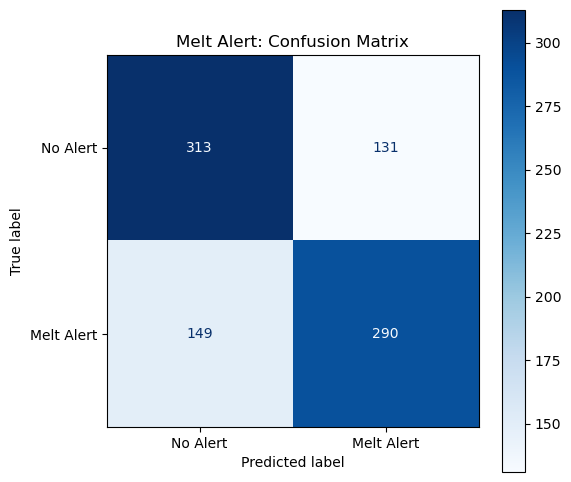

In [23]:
# Educatioanl Tip 20: We adjust the MAPE calculation so it makes sense to human beings by using MAE

from sklearn.metrics import mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. FIX THE REGRESSION METRIC (Using MAE instead of MAPE)
mae = mean_absolute_error(y_reg.iloc[train_idx:], reg_preds)
print(f"Regression MAE: {mae:.4f} Million km²")
print(f"This means on average, our 'change' prediction is off by about {mae*1e6:.0f} km².")

# 2. VISUALIZE THE CLASSIFICATION (Confusion Matrix)
cm = confusion_matrix(y_clf.iloc[train_idx:], clf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Alert', 'Melt Alert'])

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Melt Alert: Confusion Matrix')
plt.show()


# Module 21: Decision Tree Classification 

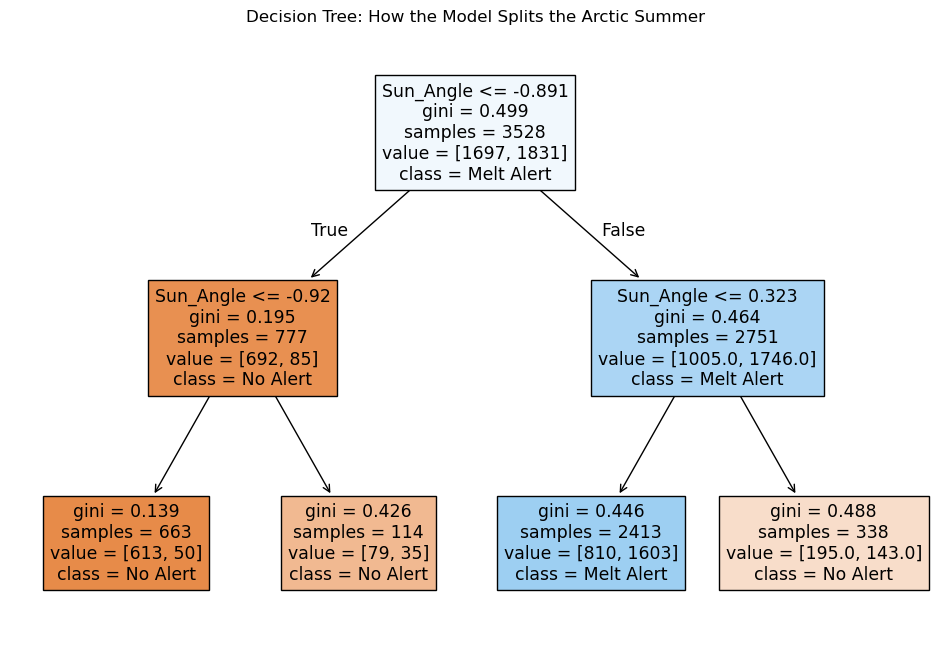

|--- Sun_Angle <= -0.89
|   |--- Sun_Angle <= -0.92
|   |   |--- class: 0
|   |--- Sun_Angle >  -0.92
|   |   |--- class: 0
|--- Sun_Angle >  -0.89
|   |--- Sun_Angle <= 0.32
|   |   |--- class: 1
|   |--- Sun_Angle >  0.32
|   |   |--- class: 0



In [24]:
# Educational Tip 21: Decision Tree Classification for MELT of the Arctic Data (seaice) 

from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Initialize the Tree
# We limit 'max_depth' to 2 so we can easily see the first few "piles"
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)

# 2. Re-define X and y specifically for classification
X_train_clf = X.iloc[:train_idx]
y_train_clf = summer['Major_Melt'].iloc[:train_idx] # Ensure these are 1s and 0s

# 3. Now fit the tree with the CLASSIFICATION labels
tree_clf.fit(X_train_clf, y_train_clf)

# 4. Visualize again
plt.figure(figsize=(12, 8))
plot_tree(tree_clf, 
          feature_names=['Lag_1', 'Sun_Angle'], 
          class_names=['No Alert', 'Melt Alert'], 
          filled=True)
plt.title("Decision Tree: How the Model Splits the Arctic Summer")
plt.show()

# to be able to share output use this code 
from sklearn.tree import export_text

# 1. Export the tree logic as text
tree_rules = export_text(tree_clf, feature_names=['Lag_1', 'Sun_Angle'])

# 2. Print it out
print(tree_rules)

In [25]:
# Final Remark
# In the 21 modules above, we explored the characteristics of Arctic Sea Ice by applying the basic principles of machine learning. 
# By prioritizing Lean Modeling, we discovered that the Solar Cycle (Sun Angle) and 
# Yesterday's Momentum (Lag) are the primary drivers of summer melt.

# Our final results—achieving a 0.70% MAPE for absolute extent and a 68% accuracy for "Major Melt" alerts—demonstrate that interpretable,
# physics-aligned models can provide powerful scientific insights without the need # for excessive complexity. 
# This notebook serves as a practice class for utilizing machine learning to monitor and predict the pulse of our changing polar environment. 
# Modified Feb. 24, 2026 by Linah Ababneh 
